# Exploratory Data Analysis of the Superstore Sales Dataset

## M504 AI and Applications – Individual Project



### Project Overview

'''In this notebook, the exploratory data analysis (EDA) of the Superstore sales dataset is presented. The objective of the analysis is to pursue trends in sales, profitability, customer segments, product categories and regional performance.

Systematic data exploration and analysis with the help of Python and Pandas allow answering a number of business-related questions within the frames of this project, which will help the retail company to learn more about its activities and facilitate data-driven decision making.

The analysis involves the data exploration, preprocessing and various business-focused analysis questions backed with visualizations and interpretations.
'''

## 1. Business Context

The data employed in this analysis is the transactional sales data of a retail superstore that is based in various parts of the United States. The company markets a very extensive variety of products that has been divided into three major categories which are Furniture, Office Supplies and Technology. The dataset will include data relating to orders of the customers, different products, the amount of sales, profit, discounts, mode of shipping, and geographical locations.

Data analysis is critical to retail companies to know their performance in terms of sales, customer purchasing behavior and profitability in the various markets they operate. The company will be able to determine the profitability of various products, regions and analysis of historical data on their transaction will help it determine the impact of factors like discounts and type of customers, among others, on profitability.

The goal of this analysis, as a data science consultant, is to undertake the analysis of the dataset and deriving meaningful information that can contribute towards enhancing business choices made by the company. These understandings may be used in strategic planning to help in product management, marketing strategies, and pricing, as well as in sales optimization in the region.

## 2. Objective of the Analysis

The primary goal of the proposed project is to conduct an exploratory data analysis (EDA) of the Superstore sales data to discover any significant patterns and create business-actionable findings. The study will use the historical data of transactions to gain better insights on the impacts of various issues like product categories, customers, regions, and discounts on total sales and profitability.

In particular, this analysis aims at answering a number of major business questions that concern the regional sales performance, product category contribution, customer buying behavior and the correlation between discounts and profits. Such insights can assist the firm to determine high performing markets, product strategies as well as to make better decisions in operations.

The information presented in such an analysis can be used by the company to create information-based strategies that would boost the revenue collection, improve profitability, and allocate resources more efficiently to various business units.


In [1]:
# Import necessary libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization style
sns.set_style("whitegrid")

# Display plots within the notebook
%matplotlib inline

In [2]:
# Load the Superstore dataset

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

# Display first few rows of the dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Display the first 10 rows of the dataset
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [4]:
# Check number of rows and columns
df.shape

(9994, 21)

In [5]:
# Display all column names in the dataset
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
# Display dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
# Generate summary statistics for numerical columns
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
# Check for missing values in each column
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
# Check number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

### Data Quality Observation

The data quality check indicates that the dataset does not contain any missing values across all columns. Each variable, including customer information, product details, sales metrics, and geographic attributes, has complete records. Additionally, the duplicate record check shows that there are no duplicated rows in the dataset. This suggests that the dataset is clean and reliable for analysis. Since there are no missing or duplicate values, no additional data cleaning steps are required at this stage before proceeding with further exploratory data analysis.

In [10]:
# Convert Order Date and Ship Date to datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check the updated data types
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [11]:
# Create a new column for Order Year

df['Order Year'] = df['Order Date'].dt.year

# Display first few values
df[['Order Date', 'Order Year']].head()

,Order Date,Order Year
0,2016-11-08,2016
1,2016-11-08,2016
2,2016-06-12,2016
3,2015-10-11,2015
4,2015-10-11,2015


In [12]:
# Create a new column for Order Month

df['Order Month'] = df['Order Date'].dt.month

# Display first few values
df[['Order Date', 'Order Month']].head()

,Order Date,Order Month
0,2016-11-08,11
1,2016-11-08,11
2,2016-06-12,6
3,2015-10-11,10
4,2015-10-11,10


### Data Preprocessing Discussion

During this step, the date based columns were transformed into relevant form of date time to facilitate proper time based analysis. Two other variables such as the Order Year and the Order Month were derived out of the Order Date column. These are additional features that enable easier trend analysis of the sales over time e.g. how the sales have increased in year by year and how the sale has performed in the dataset on monthly basis.

# Business Question 1 Description

### Business Question 1: Which region generates the highest total sales?

Knowing the sales performance in the region helps one to know the markets that are likely to be most profitable and analyzes the patterns of demand in the geographical regions. This will enable the company to understand where their products are doing well and where more work might be required through marketing or operations in various regions since the sales are directly analyzed. This understanding can be used to help the company to distribute its resources effectively and target those regions that drive the majority of total revenue.


In [13]:
# Calculate total sales by region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

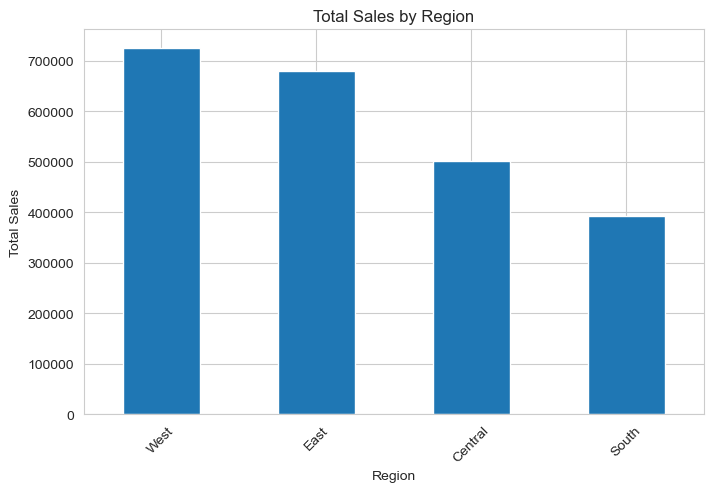

In [14]:
# Visualize sales by region

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

### Result Discussion

The analysis of total sales by region indicates that the **West region generates the highest sales**, with approximately **$725,457**, followed by the **East region** with about **$678,781**. The **Central region** contributes a moderate amount of sales at around **$501,239**, while the **South region records the lowest sales**, totaling approximately **$391,721**. 

This means that there is higher market presence and customer demand to the West and East regions. On the other hand, the South might serve as a growth opportunity in which the company can view the need to enhance the marketing strategies, availability of products, or promotion to help the company increase sales performance.

# Business Question 2 Description

### Business Question 2: Which product category generates the highest total sales?

Examination of product-based sales performance will assist the firm know the kind of products that bring the highest revenues in the total revenues. The use of this information is to plan the inventory, market and to make product portfolio decisions. Determining the most-performing categories will enable the firm to emphasize on the products that bring in revenues as well as gauge whether the non-rewarding categories need to be improved or strategic realignments made.

In [15]:
# Calculate total sales by product category

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

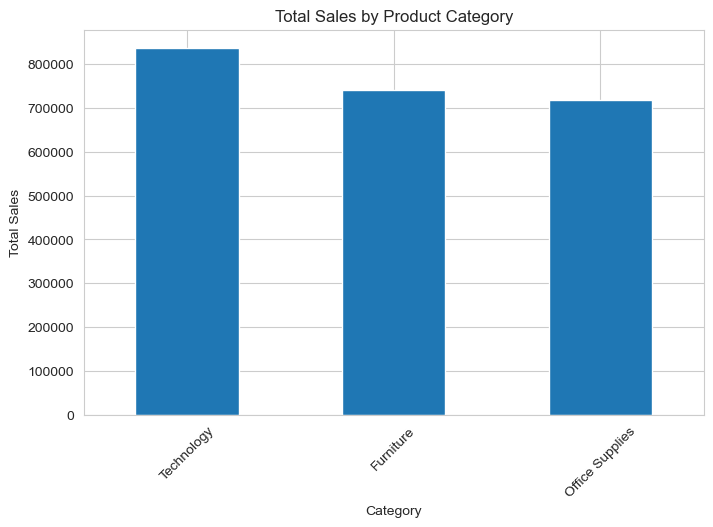

In [16]:
# Visualize sales by product category

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### Result Discussion

The analysis of sales by product category shows that **Technology generates the highest total sales**, amounting to approximately **$836,154**. This is followed by **Furniture**, which contributes around **$741,999**, while **Office Supplies records the lowest sales** among the three categories at approximately **$719,047**. 

The outcome of this is that the products produced through technology are the main revenue generators of the company meaning that there is high demand among customers in this category. Thus the company could look at broadening its prescribed technology products and aggressively market the products on this basis to generate more sales.

# Business Question 3 Description

### Business Question 3: Which customer segment contributes the most to total sales?

Knowledge on the contribution of various customer segments aids the company in finding out its most useful customer segments. In the dataset, the customers are divided into three categories which include the Consumer, Corporate, and Home Office. A comparison of sales pattern across these segments will enable the company to understand which group of customers contributes most sales and on which fronts marketing or selling campaign must be targeted.

In [17]:
# Calculate total sales by customer segment

segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

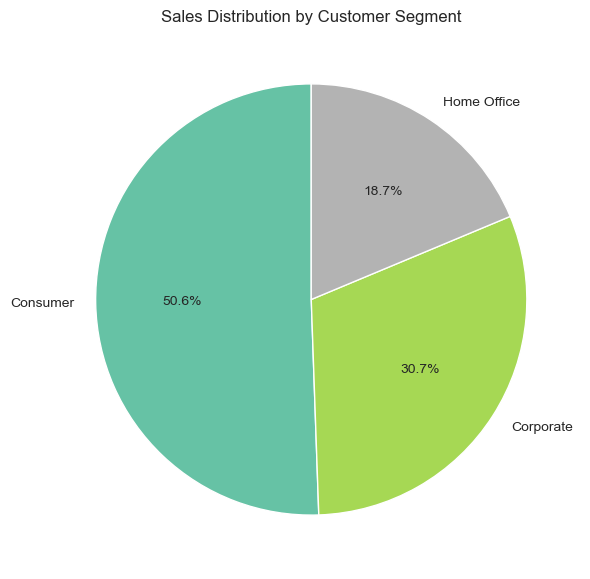

In [18]:
# Visualize sales distribution by customer segment

plt.figure(figsize=(7,7))

segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    cmap='Set2'
)

plt.title("Sales Distribution by Customer Segment")
plt.ylabel("")

plt.show()

### Result Discussion

The analysis shows that the **Consumer segment contributes the largest share of total sales**, generating approximately **$1.16 million**, which accounts for about **50.6% of total revenue**. The **Corporate segment** contributes around **30.7%**, while the **Home Office segment** represents the smallest share at **18.7%**. This indicates that individual consumers are the primary revenue drivers for the business.

# Business Question 4 Description

### Business Question 4: How have sales changed over time?

A trend analysis of sales allows the company to know whether its income is increasing or decreasing or it is flat. Analyzing the annual sales trends will allow the company to estimate the overall business performance and the times when it stalls or increases. This understanding can be useful when it comes to strategic planning, budgeting and predicting sales performance in the future.

In [19]:
# Calculate total sales by year

yearly_sales = df.groupby('Order Year')['Sales'].sum()

yearly_sales

Order Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

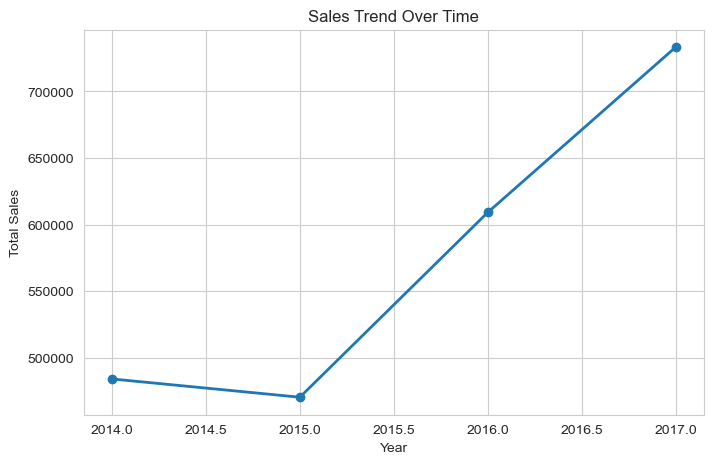

In [20]:
# Visualize sales trend over time

plt.figure(figsize=(8,5))

yearly_sales.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title("Sales Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

### Result Discussion

The sales trend analysis shows that the company experienced a slight decline in sales from **2014 ($484,247)** to **2015 ($470,532)**. However, sales increased significantly in **2016 ($609,205)** and reached the highest level in **2017 ($733,215)**. This indicates strong business growth in the later years, suggesting improving market performance and increasing customer demand.

# Business Question 5 Description

### Business Question 5: How does discount impact profit?

Companies usually use discounts as an attraction and sales promotional tool. Nevertheless, high discounts can have an adverse impact on profitability. The analysis of the correlation between the level of discounts and profit will help the company gain insight into whether an increase in discounts causes the firm to make less profit or make losses in the business. This will assist the company to have superior pricing policies and strike a balance between sales expansion and attainable profitability.

In [21]:
# Examine the relationship between discount and profit

discount_profit = df[['Discount', 'Profit']]

discount_profit.head()

,Discount,Profit
0,0.00,41.9136
1,0.00,219.5820
2,0.00,6.8714
3,0.45,-383.0310
4,0.20,2.5164


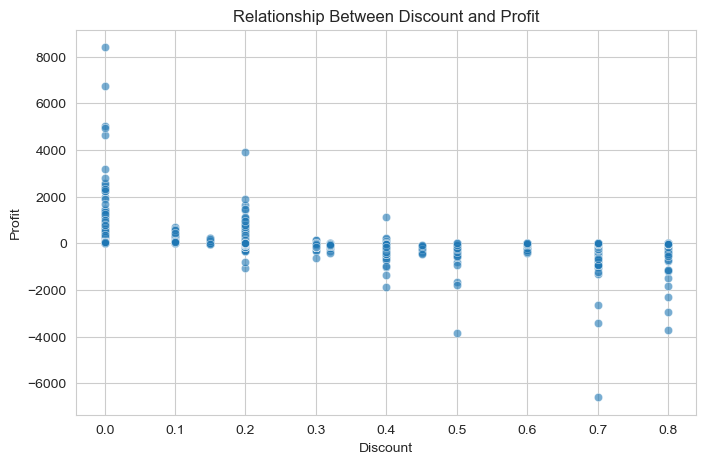

In [22]:
# Visualize the relationship between discount and profit

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.6
)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Result Discussion

The scatter plot demonstrates the correlation between the level of discount and the profit. As demonstrated in the analysis, transactions having a minimal amount of discount or no discount usually realize profits. But with high percentage of discount, the profit will be less and in many cases it will be negative. A few data data points with large discounts (approximately 0.5 to 0.8) bring about huge losses. This implies that too much discounting may have adverse effect on profitability and as such the company needs to place a close check on its discountations.

# Business Question 6 Description

### Business Question 6: Which product sub-categories generate the highest sales?

Sub-categories of products are particular lines of products in the most general categories of Furniture, Technology, and Office Supplies. By sub-categorizing the sales, the company will be able to know the kinds of products that customers like or hate. Knowledge of best-selling sub-categories enables the company to maximize the inventory, and enhance the availability of products and concentrate the marketing processes on the segments of products demanded most.

In [23]:
# Calculate total sales by product sub-category

subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

subcategory_sales

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

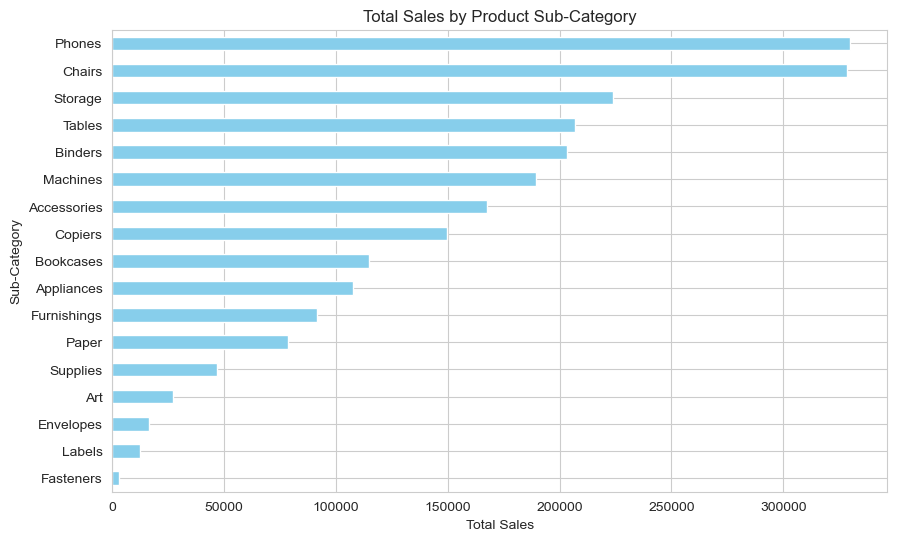

In [24]:
# Visualize sales by sub-category

plt.figure(figsize=(10,6))

subcategory_sales.plot(
    kind='barh',
    color='skyblue'
)

plt.title("Total Sales by Product Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.gca().invert_yaxis()

plt.show()

### Result Discussion

The analysis of sales by product sub-category shows that **Phones** generate the highest total sales at approximately **$330,007**, closely followed by **Chairs** with around **$328,449**. Other strong-performing sub-categories include **Storage**, **Tables**, and **Binders**. In contrast, sub-categories such as **Fasteners**, **Labels**, and **Envelopes** contribute the least to total sales. These results suggest that technology and furniture-related products are major revenue drivers, and the company should prioritize inventory management and marketing efforts for these high-performing product groups.

NEW BUSINESS QUESTION 7
📌 Which regions are most profitable (not just highest sales)?

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


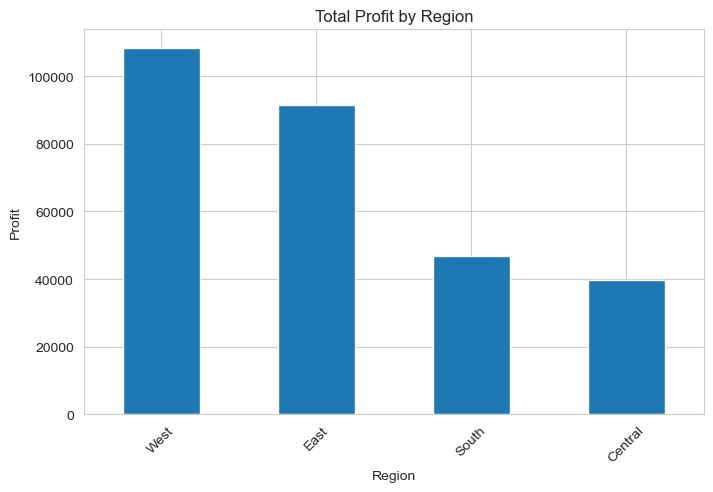

In [25]:
# Calculate total profit by region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

print(region_profit)

# Visualization
plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

Results Disscusiion
This shows total profit by region. The West region generated the highest profit, about 108,418, making it the strongest-performing area. The East region followed with around 91,523, also showing strong profitability. In contrast, the South region produced a much lower profit of about 46,749, while the Central region had the lowest profit at approximately 39,706. Overall, the chart highlights a clear regional imbalance, with West and East contributing the majority of total profit. This suggests that business performance is significantly stronger in those two regions than in South and Central.

NEW BUSINESS QUESTION 8
📌 Which product categories are most profitable?

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


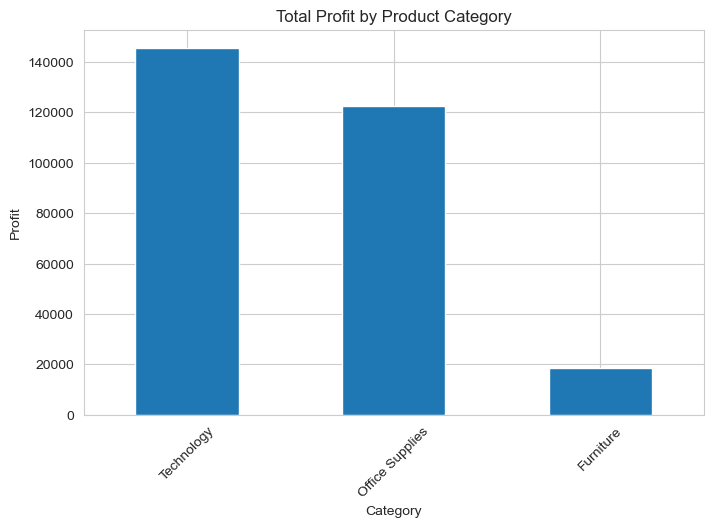

In [26]:
# Profit by category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(category_profit)

# Visualization
plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')
plt.title("Total Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

Results
This chart presents total profit by product category. Technology is the most profitable category, generating about 145,455, which makes it the strongest contributor to overall business profit. Office Supplies follows with approximately 122,491, also delivering a high level of profitability. Furniture, however, contributes only around 18,451, far below the other two categories. The large gap shows that Technology and Office Supplies are the main drivers of earnings, while Furniture performs weakly. Overall, the results suggest that the business gains most of its profit from Technology, with Furniture needing improvement or closer strategic attention.

NEW BUSINESS QUESTION 9
📌 What is the average shipping time and does it vary by ship mode?

Ship Mode
Same Day          0.044199
First Class       2.182705
Second Class      3.238046
Standard Class    5.006535
Name: Shipping Time, dtype: float64


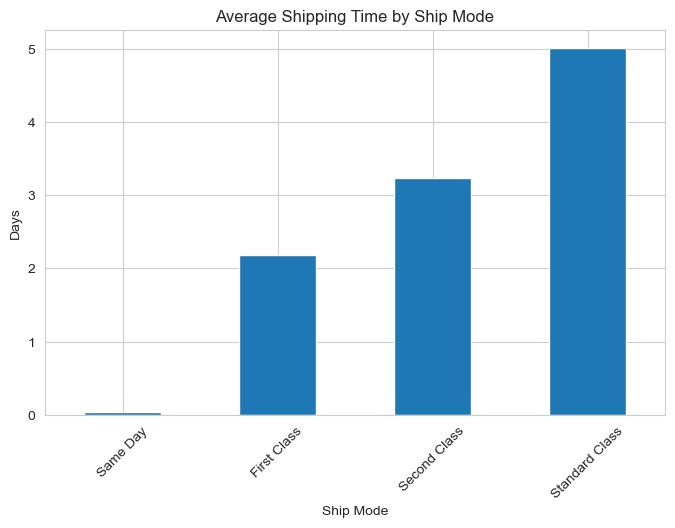

In [27]:
# Create shipping time column
df['Shipping Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Average shipping time by ship mode
shipping_time = df.groupby('Ship Mode')['Shipping Time'].mean().sort_values()

print(shipping_time)

# Visualization
plt.figure(figsize=(8,5))
shipping_time.plot(kind='bar')
plt.title("Average Shipping Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Days")
plt.xticks(rotation=45)
plt.show()

Results
This chart shows the average shipping time for each ship mode. Same Day is the fastest option, taking almost no time, with an average of about 0.04 days. First Class takes around 2.18 days, making it the next quickest delivery method. Second Class has an average shipping time of about 3.24 days, while Standard Class is the slowest at approximately 5.01 days. Overall, the chart shows a clear pattern: faster shipping modes deliver more quickly, while lower-priority options take longer to reach customers.

## Summary of Key Insights

The exploratory data analysis of the Superstore data gave some valuable business understanding. The analysis showed that the west region yields the best sales as compared to the East region with marginal difference showing that there is a greater market demand in the western parts of the country. Technology is the most important category of products, as it has shown the highest percentage of total revenue that the company generates.

Analysis of customer segments revealed that Consumer customers make the largest part of the sales as they represent more than half of the total revenue. Sales trend analysis also revealed that sales have grown substantially over the period of 2015-2017 which indicates growth in business over the last few years. Also the deepesight analysis indicated that Phones and Chairs are the most effective sub-categories of the products. The correlation between the discount and the profit shows however that greater discounts tend to result into less profit or financial loss.

## Limitations of the Analysis

Even though the analysis came up with valuable insights, there are few limitations to be taken into account. The data will be the historical sales transactions and it might not reflect the external changes like market competition, economic variables or variation in demand during the year which can affect the sales performance.

Also, the dataset lacks any more specific customer demographic data, cost structure of products, which could further reveal information about profitability and buying behavior. The analysis also dwells more on descriptive exploration than the predictive modeling and other sophisticated statistical analysis which might go a notch higher when it comes to decision-making.

## Business Recommendations

Resting on the information gained during the analysis, it is possible to give some recommendations to the company. The company should explore diversifying its activities and promotion in the technology category and sub-categories like Phones as they are already strong.

The company must also aim at sustaining good sales in the West and East regions with the possibility of expanding its sales strategies to the South and Central regions. Also, as the Consumer segment provides the highest proportion of revenues, individual customer promotions and loyalty programs can also boost the sales.

Lastly, the company should also analyze the impact that discounts might have on profitability, hence the company needs to take a prudent approach to reduce its discount strategies so that promotional approaches will not harm the overall profitability levels of the business.
